# TP InnoMoov - Détection d'anomalies avec Isolation Forest et Local Outlier Factor

Ce notebook est un **template réutilisable pour 2 datasets** en lien avec le périmètre **InnoMoov / Industrie 4.0**.

**Datasets: ai4i2020.csv et gt_2025.csv**

## Angle métier retenu
- détection d'anomalies sur des données IIoT / capteurs,
- nettoyage de datasets avant modélisation,
- détection de comportements anormaux,
- appui à la maintenance prédictive.

## Ce que fait ce notebook
1. charge les deux datasets CSV,
2. sélectionne les variables numériques,
3. gère les valeurs manquantes,
4. standardise les données,
5. applique **Isolation Forest** sur ai4i2020.csv,
6. applique **Local Outlier Factor** sur gt_2015.csv,
7. affiche des graphiques **avant / après**,
8. exporte les datasets nettoyés.


---

### 1. Import des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (7, 5)
pd.set_option('display.max_columns', 100)

### 2. Configuration des 2 datasets

In [2]:
DATASET_1 = {
    'name': 'AI4I_2020',
    'file_path': 'ai4i2020.csv',
    'sheet_name': None,
    'feature_cols': [
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ],
    'algo': 'iforest',   # uniquement Isolation Forest
    'contamination': 0.03,
    'random_state': 42
}

DATASET_2 = {
    'name': 'Gas_Turbine_2015',
    'file_path': 'gt_2015.csv',
    'sheet_name': None,
    'feature_cols': [
        'AT', 'AP', 'AH', 'AFDP', 'GTEP',
        'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX'
    ],
    'algo': 'lof',       # uniquement LOF
    'contamination': 0.03,
    'n_neighbors': 20
}

---

### 3. Fonctions utilitaires

In [3]:
def load_dataframe(file_path, sheet_name=None):
    if file_path.lower().endswith('.csv'):
        return pd.read_csv(file_path)
    elif file_path.lower().endswith(('.xlsx', '.xls')):
        return pd.read_excel(file_path, sheet_name=sheet_name)
    else:
        raise ValueError("Format non supporté")

In [4]:
def prepare_features(df, feature_cols=None):
    if feature_cols is None:
        X_df = df.select_dtypes(include=[np.number]).copy()
    else:
        X_df = df[feature_cols].copy()

    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    X_imputed = imputer.fit_transform(X_df)
    X_scaled = scaler.fit_transform(X_imputed)

    return X_df, X_scaled

In [5]:
def project_2d(X_scaled):
    if X_scaled.shape[1] == 2:
        return X_scaled
    pca = PCA(n_components=2, random_state=42)
    return pca.fit_transform(X_scaled)

In [6]:
def run_isolation_forest(X_scaled, contamination=0.03, random_state=42):
    model = IsolationForest(
        contamination=contamination,
        random_state=random_state,
        n_estimators=200
    )
    labels = model.fit_predict(X_scaled)
    scores = model.decision_function(X_scaled)
    return labels, scores

In [7]:
def run_lof(X_scaled, contamination=0.03, n_neighbors=20):
    model = LocalOutlierFactor(
        contamination=contamination,
        n_neighbors=n_neighbors
    )
    labels = model.fit_predict(X_scaled)
    scores = model.negative_outlier_factor_
    return labels, scores

In [8]:
def plot_before_after(X_2d, labels, dataset_name, algo_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(X_2d[:, 0], X_2d[:, 1])
    axes[0].set_title(f'{dataset_name} - Avant ({algo_name})')
    axes[0].set_xlabel('Axe 1')
    axes[0].set_ylabel('Axe 2')

    colors = np.where(labels == -1, 'red', 'blue')
    axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=colors)
    axes[1].set_title(f'{dataset_name} - Après ({algo_name})')
    axes[1].set_xlabel('Axe 1')
    axes[1].set_ylabel('Axe 2')

    plt.tight_layout()
    plt.show()

In [9]:
def analyse_dataset(config):
    name = config['name']
    file_path = config['file_path']
    sheet_name = config.get('sheet_name', None)
    feature_cols = config.get('feature_cols', None)
    algo = config['algo']

    df = load_dataframe(file_path, sheet_name)
    X_df, X_scaled = prepare_features(df, feature_cols)
    X_2d = project_2d(X_scaled)

    print("=" * 80)
    print(f"Analyse de : {name}")
    print(f"Algorithme choisi : {algo}")
    print("=" * 80)
    display(df.head())
    print("Dimensions :", df.shape)
    print("Variables utilisées :", list(X_df.columns))

    if algo == 'iforest':
        labels, scores = run_isolation_forest(
            X_scaled,
            contamination=config.get('contamination', 0.03),
            random_state=config.get('random_state', 42)
        )
        algo_name = "Isolation Forest"

    elif algo == 'lof':
        labels, scores = run_lof(
            X_scaled,
            contamination=config.get('contamination', 0.03),
            n_neighbors=config.get('n_neighbors', 20)
        )
        algo_name = "Local Outlier Factor"

    else:
        raise ValueError("algo doit être 'iforest' ou 'lof'")

    result = df.copy()
    result['anomaly'] = np.where(labels == -1, 1, 0)
    result['score'] = scores

    print("Nombre d'anomalies détectées :", int(result['anomaly'].sum()))
    display(result[result['anomaly'] == 1].head(10))

    plot_before_after(X_2d, labels, name, algo_name)

    df_clean = result[result['anomaly'] == 0].copy()
    output_file = f"{name}_clean_{algo}.csv"
    df_clean.to_csv(output_file, index=False)

    print("Fichier exporté :", output_file)

    return result, df_clean

---

Analyse de : AI4I_2020
Algorithme choisi : iforest


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Dimensions : (10000, 14)
Variables utilisées : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Nombre d'anomalies détectées : 300


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,anomaly,score
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0,1,-0.034702
194,195,M15054,M,298.2,308.5,2678,10.7,86,1,0,0,1,0,0,1,-0.052621
336,337,M15196,M,297.6,308.2,1995,20.5,10,0,0,0,0,0,0,1,-0.000660
344,345,M15204,M,297.5,308.2,2448,13.8,29,0,0,0,0,0,0,1,-0.052873
380,381,L47560,L,297.5,308.3,2564,12.8,127,1,0,0,1,0,0,1,-0.049275
400,401,L47580,L,297.4,308.5,2100,16.9,176,0,0,0,0,0,0,1,-0.005522
418,419,L47598,L,297.4,308.4,2151,17.7,0,0,0,0,0,0,0,1,-0.039058
463,464,L47643,L,297.4,308.7,2874,4.2,118,1,0,0,1,0,0,1,-0.052532
467,468,L47647,L,297.2,308.5,2182,16.5,127,0,0,0,0,0,0,1,-0.012580
585,586,L47765,L,297.6,309.5,2001,20.5,220,0,0,0,0,0,0,1,-0.021635


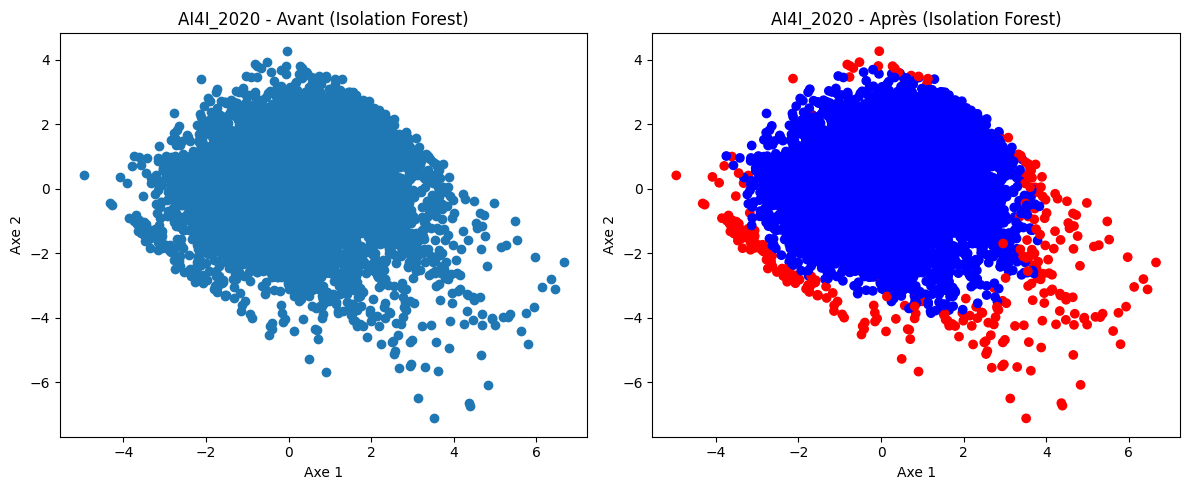

Fichier exporté : AI4I_2020_clean_iforest.csv
Analyse de : Gas_Turbine_2015
Algorithme choisi : lof


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,1.95320,1020.1,84.985,2.5304,20.116,1048.7,544.92,116.27,10.799,7.4491,113.250
1,1.21910,1020.1,87.523,2.3937,18.584,1045.5,548.50,109.18,10.347,6.4684,112.020
2,0.94915,1022.2,78.335,2.7789,22.264,1068.8,549.95,125.88,11.256,3.6335,88.147
3,1.00750,1021.7,76.942,2.8170,23.358,1075.2,549.63,132.21,11.702,3.1972,87.078
4,1.28580,1021.6,76.732,2.8377,23.483,1076.2,549.68,133.58,11.737,2.3833,82.515


Dimensions : (7384, 11)
Variables utilisées : ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']
Nombre d'anomalies détectées : 222


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,anomaly,score
17,0.059447,1026.0,52.124,2.4651,18.478,1048.4,548.78,111.20,10.384,4.6896,104.560,1,-1.577099
19,0.016700,1026.8,54.805,3.3399,27.408,1085.6,540.72,148.05,12.790,3.8632,75.640,1,-1.653890
36,-1.178200,1022.1,71.123,2.5283,19.552,1034.3,536.35,112.69,10.667,3.4947,110.990,1,-1.659112
52,1.830000,1020.5,73.273,3.5265,29.696,1087.6,538.34,151.67,13.083,3.6218,72.238,1,-1.554543
81,3.640700,1012.2,67.552,3.2381,26.106,1084.6,545.87,142.24,12.351,3.4647,75.028,1,-1.596121
105,1.848800,1008.4,65.453,3.6053,29.367,1086.4,536.74,150.97,13.128,4.0116,77.148,1,-1.632636
121,-1.708800,1022.3,66.518,3.1020,25.260,1083.6,547.21,142.16,12.296,4.1911,85.733,1,-1.533691
122,-2.284500,1023.4,65.756,3.3795,28.111,1099.8,547.09,155.12,13.069,2.8775,79.495,1,-1.994243
123,-3.065900,1024.4,62.778,3.7903,31.894,1099.8,534.48,164.78,13.885,2.8084,68.658,1,-1.641420
124,-3.303800,1025.4,59.547,3.5164,29.580,1100.2,542.49,159.23,13.375,2.8682,75.366,1,-1.626313


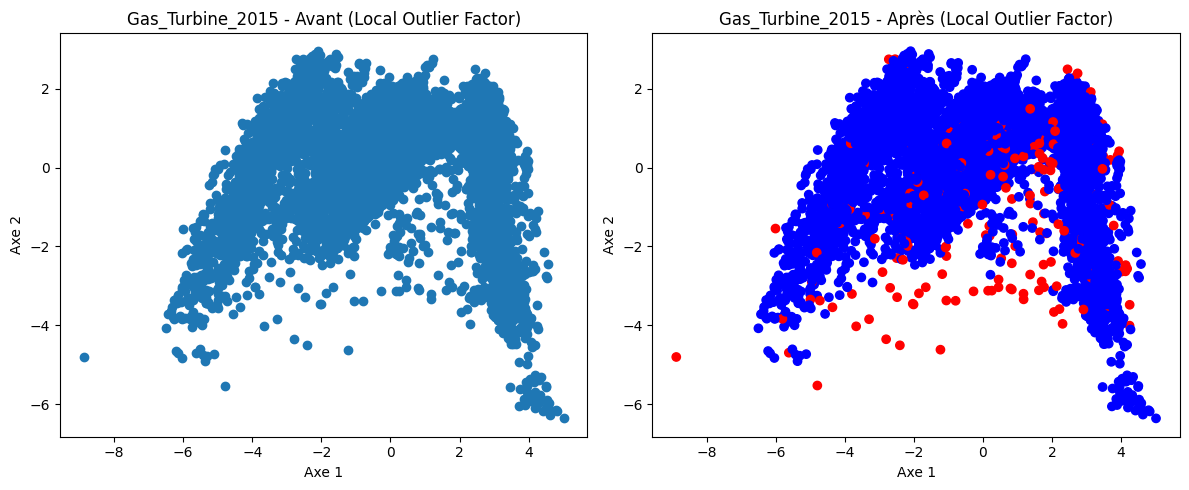

Fichier exporté : Gas_Turbine_2015_clean_lof.csv


In [10]:
result_1, clean_1 = analyse_dataset(DATASET_1)
result_2, clean_2 = analyse_dataset(DATASET_2)

---

## 4. Interprétation métier InnoMoov

### Cas 1 - dataset capteurs IIoT
Des anomalies sur la température, la vibration, la pression ou la consommation énergétique peuvent signaler :
- une dérive machine,
- un capteur défaillant,
- un mauvais réglage,
- un risque d'arrêt ou de maintenance.

### Cas 2 - dataset production / qualité
Des anomalies sur le temps de cycle, le rebut, l'énergie ou la cadence peuvent signaler :
- une baisse de performance,
- une non-qualité,
- une rupture de comportement normal,
- un besoin de nettoyage du dataset avant modélisation.
